In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# 2. Load Dataset

data = pd.read_csv("diabetes.csv")

print(data.head())
print(data.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [3]:
# 3. Split Features and Target

X = data.drop("Outcome", axis=1)
y = data["Outcome"]


In [4]:
# 4. Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# 5. Standardization

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# 6. Logistic Regression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.7532467532467533


In [7]:
# 7. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[79 20]
 [18 37]]


In [8]:
# 8. Decision Tree Model

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7597402597402597


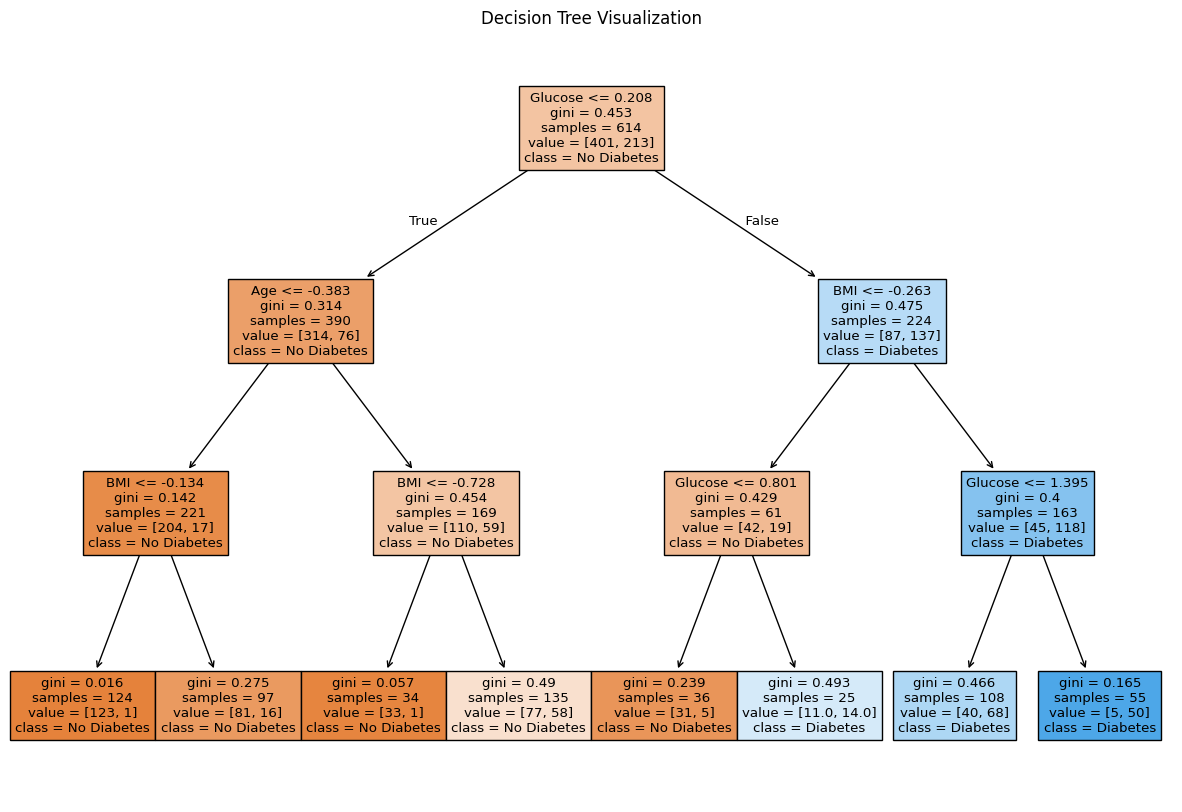

In [9]:
# 9. Decision Tree Diagram

plt.figure(figsize=(15,10))

plot_tree(
    dt_model,
    feature_names=data.drop("Outcome", axis=1).columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()

In [10]:
# 10. Random Forest Model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7207792207792207


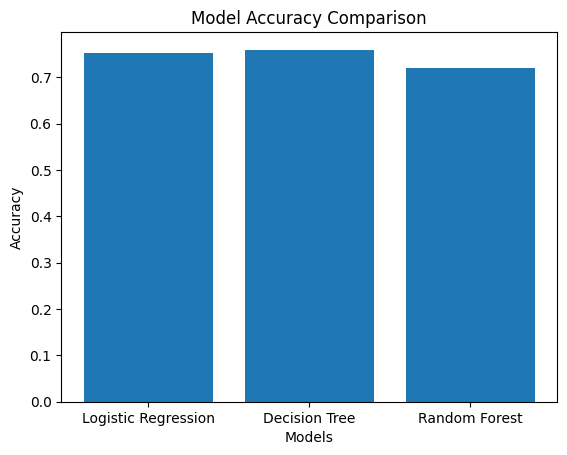

In [11]:
# 11. Accuracy Comparison Graph

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
scores = [log_accuracy, dt_accuracy, rf_accuracy]

plt.figure()

plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


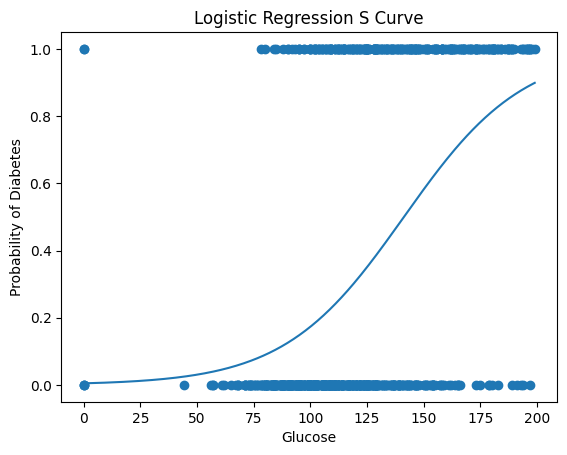

In [12]:
# 12. Logistic Regression S Curve

X_glucose = data[['Glucose']]
y_outcome = data['Outcome']

model2 = LogisticRegression()
model2.fit(X_glucose, y_outcome)

x_values = np.linspace(data['Glucose'].min(), data['Glucose'].max(), 300)
y_prob = model2.predict_proba(x_values.reshape(-1,1))[:,1]

plt.scatter(data['Glucose'], y_outcome)
plt.plot(x_values, y_prob)

plt.xlabel("Glucose")
plt.ylabel("Probability of Diabetes")
plt.title("Logistic Regression S Curve")

plt.show()

In [13]:
print("Logistic Regression Accuracy:", log_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.7532467532467533
Decision Tree Accuracy: 0.7597402597402597
Random Forest Accuracy: 0.7207792207792207


In [14]:
# 13. Best Model

models_dict = {
    "Logistic Regression": log_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy
}

best_model = max(models_dict, key=models_dict.get)

print("Best Model:", best_model)

Best Model: Decision Tree
